In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan.csv")

In [3]:
df.head()
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


Handling missing value


In [4]:
# sparted numarical and categorical data
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include =["number"]).columns

In [5]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [6]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [7]:
categorical_cols.size+numerical_cols.size

20

In [8]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [9]:
df.head()
df.isnull().sum()

Applicant_ID           0
Applicant_Income       0
Coapplicant_Income     0
Employment_Status     50
Age                    0
Marital_Status        50
Dependents             0
Credit_Score           0
Existing_Loans         0
DTI_Ratio              0
Savings                0
Collateral_Value       0
Loan_Amount            0
Loan_Term              0
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [10]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

EDA


Text(0.5, 1.0, 'Is Loan Approved or not ?')

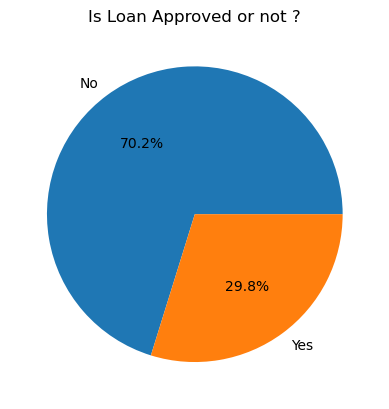

In [11]:
# how blanced our classes are?

class_count = df["Loan_Approved"].value_counts()
plt.pie(class_count,labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is Loan Approved or not ?")

[Text(0, 0, '722'), Text(0, 0, '278')]

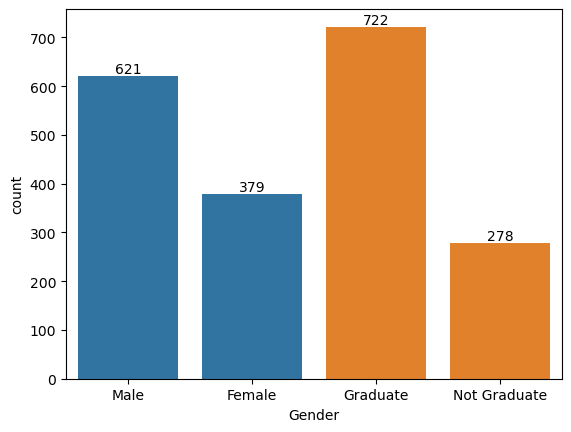

In [12]:
gender_cnt  =df["Gender"].value_counts()
ax =sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[1])


<Axes: xlabel='Applicant_Income', ylabel='Count'>

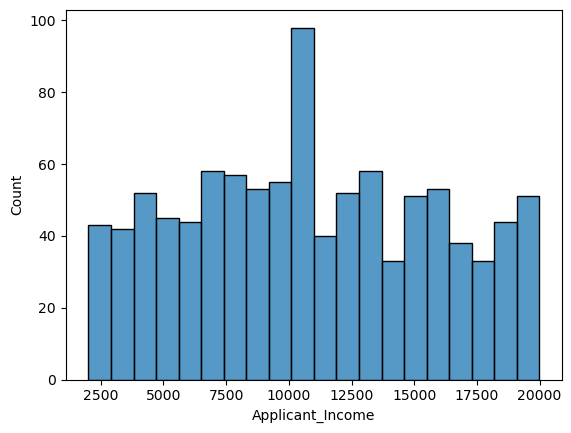

In [13]:
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

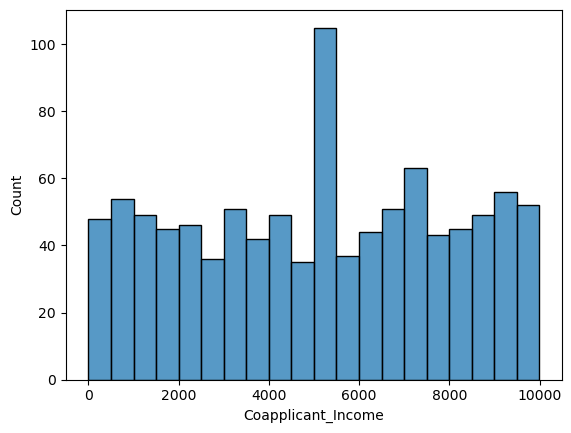

In [14]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

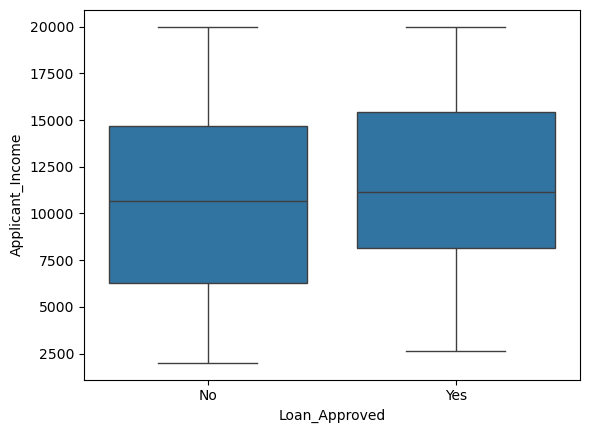

In [15]:
# outliers-box plots
sns.boxplot(
    data = df,
    x="Loan_Approved",
    y="Applicant_Income"
)



In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

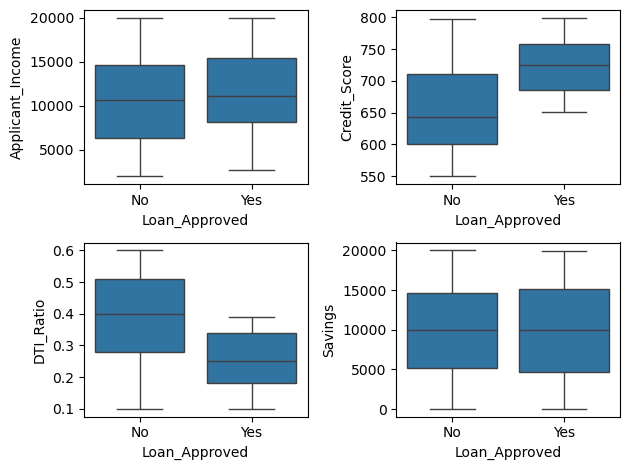

In [17]:
fig,axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax = axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax = axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax = axes[1,1],data=df,x="Loan_Approved",y="Savings")
plt.tight_layout()

Encoding


In [18]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [19]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

In [21]:
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
cols = ["Employer_Category","Gender","Property_Area","Marital_Status","Employment_Status"]

In [22]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [23]:
print(df.columns)

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='object')


In [24]:
cols = ["Employer_Category","Gender","Property_Area","Marital_Status","Employment_Status"]

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)


In [25]:
df.head()
df.info

<bound method DataFrame.info of      Applicant_ID  Applicant_Income  Coapplicant_Income   Age  Dependents  \
0             1.0      17795.000000              1387.0  51.0         0.0   
1             2.0       2860.000000              2679.0  46.0         3.0   
2             3.0       7390.000000              2106.0  25.0         2.0   
3             4.0      13964.000000              8173.0  40.0         2.0   
4             5.0      13284.000000              4223.0  31.0         2.0   
..            ...               ...                 ...   ...         ...   
995         996.0      10852.571579              9092.0  58.0         0.0   
996         997.0       3279.000000              6356.0  58.0         1.0   
997         998.0      15192.000000              8433.0  48.0         1.0   
998         999.0       9083.000000              7380.0  50.0         1.0   
999        1000.0      13093.000000              2385.0  23.0         1.0   

     Credit_Score  Existing_Loans  DTI_Rati

Correlation Matrixs

<Axes: >

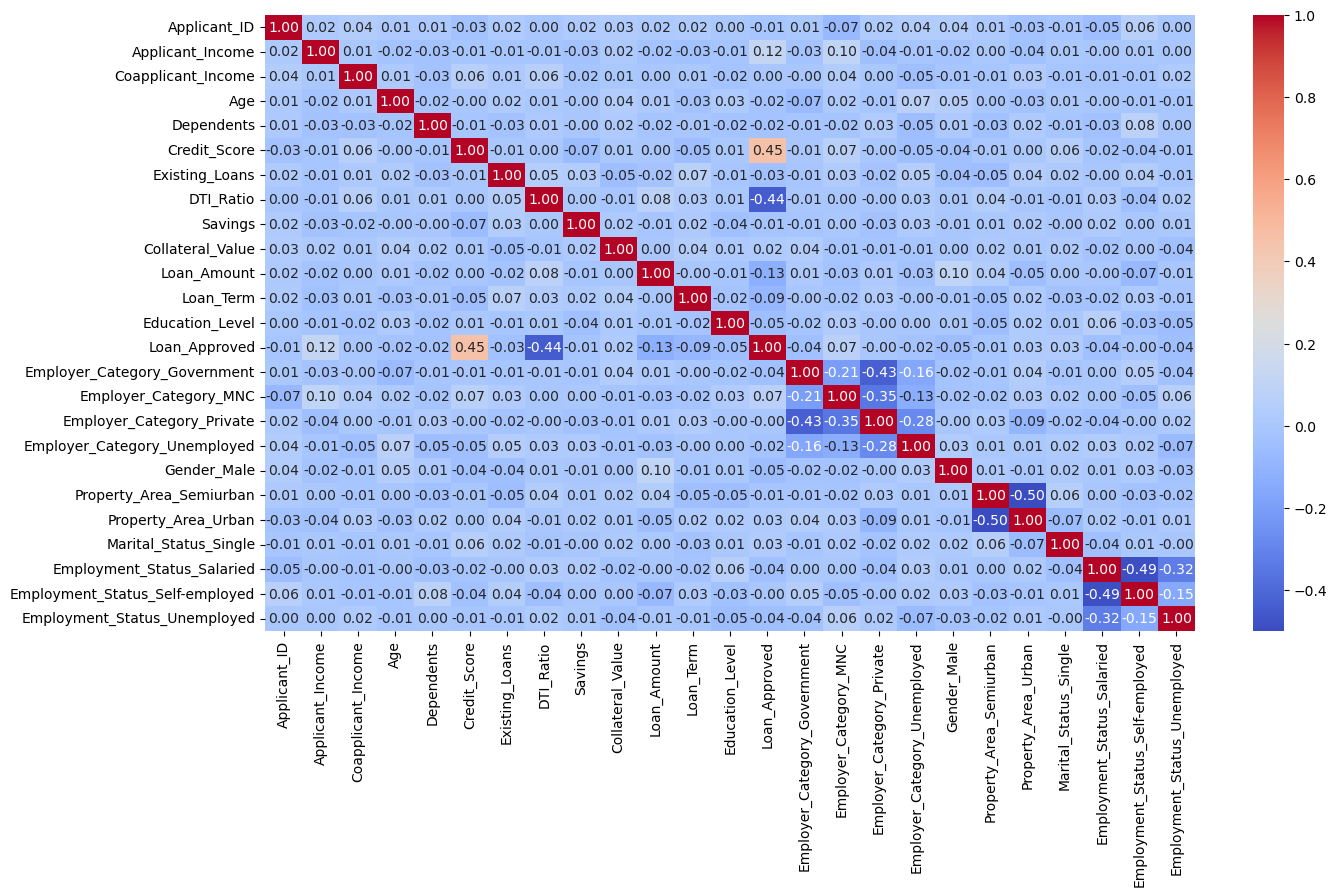

In [26]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

In [27]:
corr_matrix

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male,Property_Area_Semiurban,Property_Area_Urban,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
Applicant_ID,1.000000,0.020970,0.041140,0.014579,0.012495,-0.028170,0.024995,0.000174,0.022692,0.031759,...,-0.074056,0.022803,0.038417,0.036067,0.012969,-0.030187,-0.010343,-0.051523,0.059238,0.002965
Applicant_Income,0.020970,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,...,0.102589,-0.044639,-0.011995,-0.020871,0.004845,-0.036260,0.010057,-0.000863,0.005609,0.001419
Coapplicant_Income,0.041140,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,...,0.037640,0.004312,-0.047929,-0.010148,-0.010058,0.030045,-0.011431,-0.013517,-0.010462,0.023114
Age,0.014579,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,...,0.021232,-0.012960,0.072462,0.048402,0.003100,-0.025661,0.009162,-0.000167,-0.011743,-0.009866
Dependents,0.012495,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,...,-0.018757,0.030197,-0.054147,0.013706,-0.032278,0.024082,-0.011410,-0.034611,0.079136,0.000396
Credit_Score,-0.028170,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,...,0.066736,-0.000049,-0.046087,-0.039739,-0.006946,0.004445,0.056176,-0.016627,-0.035896,-0.008344
Existing_Loans,0.024995,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,...,0.030520,-0.019306,0.045391,-0.038762,-0.053971,0.035629,0.018010,-0.004462,0.042772,-0.012356
DTI_Ratio,0.000174,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,...,0.002090,-0.003506,0.026018,0.009624,0.044898,-0.006156,-0.014850,0.031658,-0.043904,0.022318
Savings,0.022692,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,...,0.004381,-0.030208,0.027178,-0.006667,0.005438,0.016833,-0.004131,0.022435,0.000668,0.006304
Collateral_Value,0.031759,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,...,-0.013464,-0.014480,-0.009655,0.000897,0.020061,0.007975,0.018450,-0.019882,0.000119,-0.041632


In [28]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Applicant_ID                      -0.011167
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                   -0.052920
Gender_Male                       -0.054342
Loan_Term                       

Train_test_split

In [29]:
x = df.drop("Loan_Approved",axis = 1)
y = df["Loan_Approved"]

In [30]:
x.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male,Property_Area_Semiurban,Property_Area_Urban,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


In [31]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [32]:
x_train ,x_test,y_train,y_test = train_test_split(x,y,test_size =0.2,random_state = 42)

In [33]:
x_test.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,Gender_Male,Property_Area_Semiurban,Property_Area_Urban,Marital_Status_Single,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed
521,522.0,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0
737,738.0,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
740,741.0,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
660,661.0,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
411,412.0,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [34]:
x_train.select_dtypes(include="object").columns

Index(['Loan_Purpose'], dtype='object')

In [35]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)

encoded_train = ohe.fit_transform(x_train[["Loan_Purpose"]])

encoded_train_df = pd.DataFrame(
    encoded_train,
    columns=ohe.get_feature_names_out(["Loan_Purpose"]),
    index=x_train.index
)

encoded_test = ohe.transform(x_test[["Loan_Purpose"]])

encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=ohe.get_feature_names_out(["Loan_Purpose"]),
    index=x_test.index
)

x_train = pd.concat([x_train.drop("Loan_Purpose", axis=1), encoded_train_df], axis=1)
x_test = pd.concat([x_test.drop("Loan_Purpose", axis=1), encoded_test_df], axis=1)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [37]:
x_test_scaled

array([[ 0.07859054,  0.42610546,  0.55091079, ..., -0.48038446,
        -0.48825208, -0.46454867],
       [ 0.84335174,  1.00971366,  0.58995935, ..., -0.48038446,
         2.04812236, -0.46454867],
       [ 0.85397342, -0.67557096, -0.54558674, ..., -0.48038446,
        -0.48825208, -0.46454867],
       ...,
       [-1.02960507, -0.67980585, -0.10106072, ..., -0.48038446,
        -0.48825208, -0.46454867],
       [ 0.40432216, -0.37650705, -0.97825874, ...,  2.081666  ,
        -0.48825208, -0.46454867],
       [-1.48987801, -0.73647272, -1.24497436, ..., -0.48038446,
        -0.48825208, -0.46454867]], shape=(200, 28))

# train and evaluate model


In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)

y_pred = log_model.predict(x_test_scaled)

print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred)) 
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))

precision: 0.7868852459016393
recall: 0.7868852459016393
f1_score: 0.7868852459016393
accuracy_score: 0.87
confusion_matrix: [[126  13]
 [ 13  48]]


In [41]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)
y_pred = knn_model.predict(x_test_scaled)
print("KNN Model")
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred)) 
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))

KNN Model
precision: 0.5957446808510638
recall: 0.45901639344262296
f1_score: 0.5185185185185185
accuracy_score: 0.74
confusion_matrix: [[120  19]
 [ 33  28]]


In [42]:
#GaussianNB
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
gnb_model = GaussianNB()
gnb_model.fit(x_train_scaled, y_train)
y_pred = gnb_model.predict(x_test_scaled)
print("GaussianNB Model")
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred)) 
print("f1_score:", f1_score(y_test, y_pred)) 
print("accuracy_score:", accuracy_score(y_test, y_pred))
print("confusion_matrix:", confusion_matrix(y_test, y_pred))

GaussianNB Model
precision: 0.8035714285714286
recall: 0.7377049180327869
f1_score: 0.7692307692307693
accuracy_score: 0.865
confusion_matrix: [[128  11]
 [ 16  45]]
